In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from ydata_profiling import ProfileReport

In [2]:
df = pd.read_csv('/home/kevin/Downloads/Mobile money/Mobile Payments.csv')
df.head()

,Year,Month,Active Agents,Total Registered Mobile Money Accounts (Millions),Total Agent Cash in Cash Out (Volume Million),Total Agent Cash in Cash Out (Value KSh billions)
0,2023,August,333428,77.55,208.61,666.63
1,2023,July,330912,77.21,202.85,684.64
2,2023,June,328543,76.99,197.42,643.76
3,2023,May,334726,77.34,205.88,670.44
4,2023,April,329968,75.96,194.95,615.25


Data features: Columns present in the dataset are year, month, active agents, total registered mobile money accounts, total agent cash in cash out volume and total agent cash in cash out value.

Data Features Meaning:

Year: Annual fiscal year mobile money transactions occur in Kenya

Month: Monthly data for mobile money transactions

Total registered mobile money accounts: Number of users who have registered mobile money accounts

Total agent cash in cash out volume: Quantity of mobile money transactions as per records of mobile money agents. Mobile money agents are small mobile phone stores or retail locations—which allow users to 
deposit and withdraw in-person. Cash in represent deposits and cash out represent cash withdrawals

Total cash in cash out value: Monetary value of all mobile money transactions that occurred in Kenya from January 2007 to August 2023



In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198 entries, 0 to 197
Data columns (total 6 columns):
 #   Column                                             Non-Null Count  Dtype  
---  ------                                             --------------  -----  
 0   Year                                               198 non-null    int64  
 1   Month                                              198 non-null    object 
 2   Active Agents                                      198 non-null    int64  
 3   Total Registered Mobile Money Accounts (Millions)  198 non-null    float64
 4   Total Agent Cash in Cash Out (Volume Million)      198 non-null    float64
 5   Total Agent Cash in Cash Out (Value KSh billions)  198 non-null    float64
dtypes: float64(3), int64(2), object(1)
memory usage: 9.4+ KB


In [4]:
df.shape

(198, 6)

In [5]:
df.rename(columns={'Total Agent Cash in Cash Out (Value KSh billions)':'Total_Agent_Cash_in_Cash_Out_Value_KSh_billions'}, inplace=True)
df.rename(columns={'Total Agent Cash in Cash Out (Volume Million)':'Total_Agent_Cash_in_Cash_Out_Volume_millions'}, inplace=True)
df.rename(columns={'Total Registered Mobile Money Accounts (Millions)':'Total_Registered_Mobile_Money_Accounts_Millions'}, inplace=True)
df.rename(columns={'Active Agents':'Active_Agents'}, inplace=True)

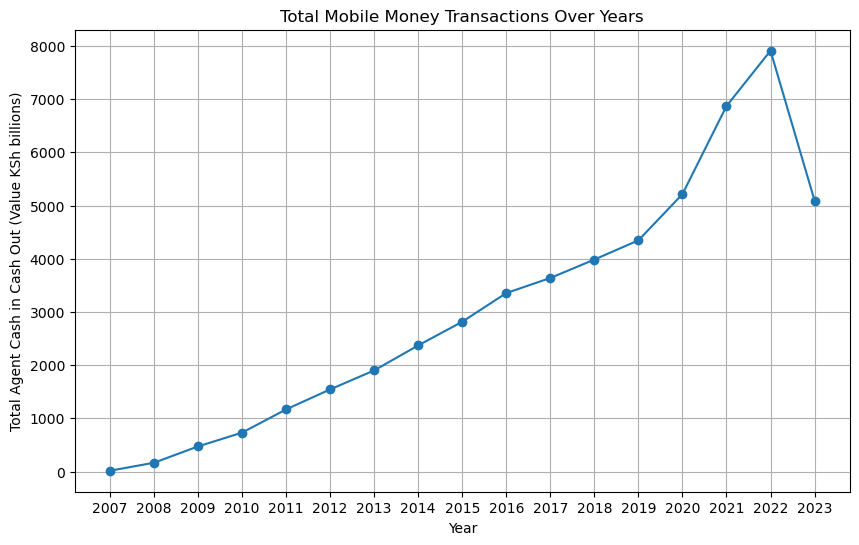

In [6]:
df_o = df.groupby('Year')['Total_Agent_Cash_in_Cash_Out_Value_KSh_billions'].sum().reset_index()
plt.figure(figsize=(10,6))
plt.plot(df_o['Year'], df_o['Total_Agent_Cash_in_Cash_Out_Value_KSh_billions'], marker='o')
plt.title('Total Mobile Money Transactions Over Years')
plt.xlabel('Year')
plt.ylabel('Total Agent Cash in Cash Out (Value KSh billions)')
plt.xticks(df_o['Year'])
plt.grid()
plt.show()

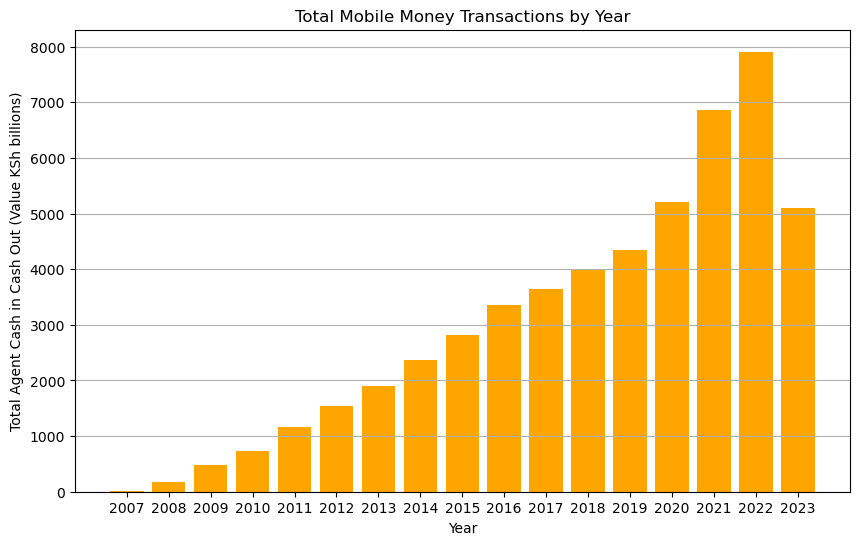

In [7]:
plt.figure(figsize=(10,6))
plt.bar(df_o['Year'], df_o['Total_Agent_Cash_in_Cash_Out_Value_KSh_billions'], color='orange')
plt.title('Total Mobile Money Transactions by Year')
plt.xlabel('Year')
plt.ylabel('Total Agent Cash in Cash Out (Value KSh billions)')
plt.xticks(df_o['Year'])
plt.grid(axis='y')
plt.show()

In [8]:
ProfileReport(df)

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 6/6 [00:00<00:00, 23.68it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [9]:
list_cat = df['Month'].unique().tolist()
list_cat

['August',
 'July',
 'June',
 'May',
 'April',
 'March',
 'February',
 'January',
 'December',
 'November',
 'October',
 'September']

In [10]:
order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
from sklearn.preprocessing import OrdinalEncoder
encode = OrdinalEncoder(categories=[order])
df['Month_encoded'] = encode.fit_transform(df[['Month']])
df['Month_encoded'] = df['Month_encoded']+1
df.head()

,Year,Month,Active_Agents,Total_Registered_Mobile_Money_Accounts_Millions,Total_Agent_Cash_in_Cash_Out_Volume_millions,Total_Agent_Cash_in_Cash_Out_Value_KSh_billions,Month_encoded
0,2023,August,333428,77.55,208.61,666.63,8.0
1,2023,July,330912,77.21,202.85,684.64,7.0
2,2023,June,328543,76.99,197.42,643.76,6.0
3,2023,May,334726,77.34,205.88,670.44,5.0
4,2023,April,329968,75.96,194.95,615.25,4.0


In [11]:

df["month_sin"] = np.sin(2 * np.pi * df["Month_encoded"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["Month_encoded"] / 12)
df.head()

,Year,Month,Active_Agents,Total_Registered_Mobile_Money_Accounts_Millions,Total_Agent_Cash_in_Cash_Out_Volume_millions,Total_Agent_Cash_in_Cash_Out_Value_KSh_billions,Month_encoded,month_sin,month_cos
0,2023,August,333428,77.55,208.61,666.63,8.0,-8.660254e-01,-0.500000
1,2023,July,330912,77.21,202.85,684.64,7.0,-5.000000e-01,-0.866025
2,2023,June,328543,76.99,197.42,643.76,6.0,1.224647e-16,-1.000000
3,2023,May,334726,77.34,205.88,670.44,5.0,5.000000e-01,-0.866025
4,2023,April,329968,75.96,194.95,615.25,4.0,8.660254e-01,-0.500000


In [12]:
df['date'] = pd.to_datetime(dict(year=df['Year'], month=df['Month_encoded'], day=1))
df.head()

,Year,Month,Active_Agents,Total_Registered_Mobile_Money_Accounts_Millions,Total_Agent_Cash_in_Cash_Out_Volume_millions,Total_Agent_Cash_in_Cash_Out_Value_KSh_billions,Month_encoded,month_sin,month_cos,date
0,2023,August,333428,77.55,208.61,666.63,8.0,-8.660254e-01,-0.500000,2023-08-01
1,2023,July,330912,77.21,202.85,684.64,7.0,-5.000000e-01,-0.866025,2023-07-01
2,2023,June,328543,76.99,197.42,643.76,6.0,1.224647e-16,-1.000000,2023-06-01
3,2023,May,334726,77.34,205.88,670.44,5.0,5.000000e-01,-0.866025,2023-05-01
4,2023,April,329968,75.96,194.95,615.25,4.0,8.660254e-01,-0.500000,2023-04-01


In [13]:
ProfileReport(df)

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 10/10 [00:00<00:00, 88115.63it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Target Variable: Total_Agent_Cash_in_Cash_Out_Value_KSh_billions

In [14]:
df['Y'] = df['Total_Agent_Cash_in_Cash_Out_Value_KSh_billions'].shift(-1)
df['Y_log'] = np.log1p(df['Y'])
df.head()

,Year,Month,Active_Agents,Total_Registered_Mobile_Money_Accounts_Millions,Total_Agent_Cash_in_Cash_Out_Volume_millions,Total_Agent_Cash_in_Cash_Out_Value_KSh_billions,Month_encoded,month_sin,month_cos,date,Y,Y_log
0,2023,August,333428,77.55,208.61,666.63,8.0,-8.660254e-01,-0.500000,2023-08-01,684.64,6.530353
1,2023,July,330912,77.21,202.85,684.64,7.0,-5.000000e-01,-0.866025,2023-07-01,643.76,6.468878
2,2023,June,328543,76.99,197.42,643.76,6.0,1.224647e-16,-1.000000,2023-06-01,670.44,6.509425
3,2023,May,334726,77.34,205.88,670.44,5.0,5.000000e-01,-0.866025,2023-05-01,615.25,6.423653
4,2023,April,329968,75.96,194.95,615.25,4.0,8.660254e-01,-0.500000,2023-04-01,645.80,6.472037


In [15]:
df = df.sort_values("date").reset_index(drop=True)
df

,Year,Month,Active_Agents,Total_Registered_Mobile_Money_Accounts_Millions,Total_Agent_Cash_in_Cash_Out_Volume_millions,Total_Agent_Cash_in_Cash_Out_Value_KSh_billions,Month_encoded,month_sin,month_cos,date,Y,Y_log
0,2007,March,307,0.020992,0.021714,0.064391,3.0,1.000000e+00,6.123234e-17,2007-03-01,NaN,NaN
1,2007,April,362,0.054944,0.070000,0.220896,4.0,8.660254e-01,-5.000000e-01,2007-04-01,0.064391,0.062402
2,2007,May,447,0.107733,0.150000,0.483709,5.0,5.000000e-01,-8.660254e-01,2007-05-01,0.220896,0.199585
3,2007,June,527,0.175652,0.233661,0.720102,6.0,1.224647e-16,-1.000000e+00,2007-06-01,0.483709,0.394545
4,2007,July,681,0.268499,0.354298,1.065370,7.0,-5.000000e-01,-8.660254e-01,2007-07-01,0.720102,0.542384
...,...,...,...,...,...,...,...,...,...,...,...,...
193,2023,April,329968,75.960000,194.950000,615.250000,4.0,8.660254e-01,-5.000000e-01,2023-04-01,645.800000,6.472037
194,2023,May,334726,77.340000,205.880000,670.440000,5.0,5.000000e-01,-8.660254e-01,2023-05-01,615.250000,6.423653
195,2023,June,328543,76.990000,197.420000,643.760000,6.0,1.224647e-16,-1.000000e+00,2023-06-01,670.440000,6.509425
196,2023,July,330912,77.210000,202.850000,684.640000,7.0,-5.000000e-01,-8.660254e-01,2023-07-01,643.760000,6.468878


In [16]:
base_col = "Total_Agent_Cash_in_Cash_Out_Value_KSh_billions"

df["lag1"]  = df[base_col].shift(1)
df["lag3"]  = df[base_col].shift(3)
df["lag12"] = df[base_col].shift(12)

df["Y"] = df[base_col].shift(-1)
df["Y_log"] = np.log1p(df["Y"])

df = df.dropna()

df

,Year,Month,Active_Agents,Total_Registered_Mobile_Money_Accounts_Millions,Total_Agent_Cash_in_Cash_Out_Volume_millions,Total_Agent_Cash_in_Cash_Out_Value_KSh_billions,Month_encoded,month_sin,month_cos,date,Y,Y_log,lag1,lag3,lag12
12,2008,March,2329,2.07553,2.39750,6.74745,3.0,1.000000e+00,6.123234e-17,2008-03-01,8.38964,2.239607,5.21979,3.77027,0.064391
13,2008,April,2606,2.37346,3.07289,8.38964,4.0,8.660254e-01,-5.000000e-01,2008-04-01,10.90420,2.476891,6.74745,4.05904,0.220896
14,2008,May,2770,2.71813,4.02127,10.90420,5.0,5.000000e-01,-8.660254e-01,2008-05-01,10.91720,2.477983,8.38964,5.21979,0.483709
15,2008,June,3011,3.03852,4.20144,10.91720,6.0,1.224647e-16,-1.000000e+00,2008-06-01,14.01710,2.709190,10.90420,6.74745,0.720102
16,2008,July,3378,3.36719,5.39108,14.01710,7.0,-5.000000e-01,-8.660254e-01,2008-07-01,16.75630,2.876740,10.91720,8.38964,1.065370
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
192,2023,March,321149,73.72000,204.83000,645.80000,3.0,1.000000e+00,6.123234e-17,2023-03-01,615.25000,6.423653,578.09000,708.06000,664.310000
193,2023,April,329968,75.96000,194.95000,615.25000,4.0,8.660254e-01,-5.000000e-01,2023-04-01,670.44000,6.509425,645.80000,589.30000,663.530000
194,2023,May,334726,77.34000,205.88000,670.44000,5.0,5.000000e-01,-8.660254e-01,2023-05-01,643.76000,6.468878,615.25000,578.09000,692.620000
195,2023,June,328543,76.99000,197.42000,643.76000,6.0,1.224647e-16,-1.000000e+00,2023-06-01,684.64000,6.530353,670.44000,645.80000,665.090000


In [17]:
df.drop(columns=['Month', 'Month_encoded', 'Year'], inplace=True)

/tmp/ipykernel_5410/3996478223.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns=['Month', 'Month_encoded', 'Year'], inplace=True)


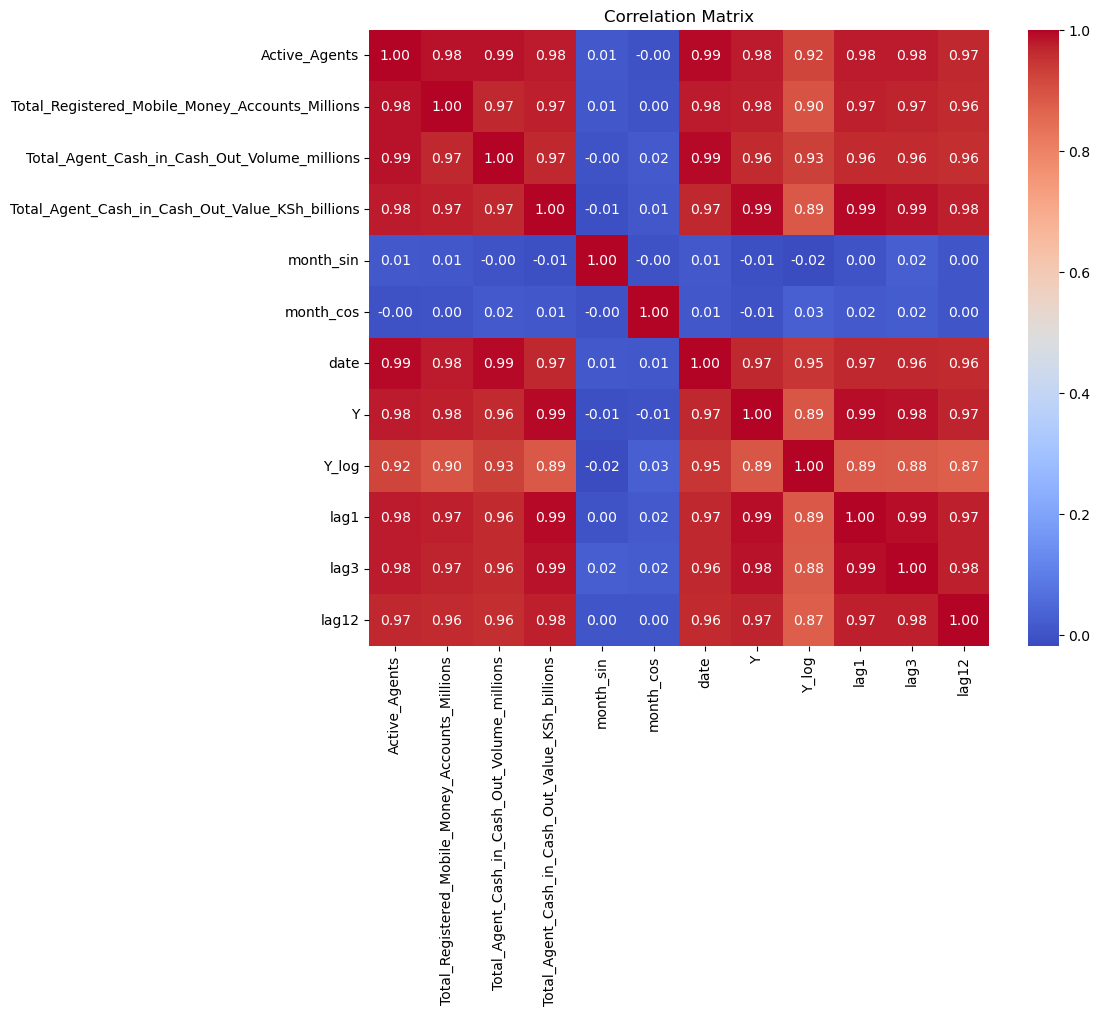

In [18]:
corr = df.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

The correlation matrix reveals a strong temporal dependence of the variables, indicating that the high correlations are primarily due to trend. The final selection of variables was therefore based on temporal lags and seasonal components rather than raw correlations.

In [19]:
split_idx = int(len(df) * 0.8)

train = df.iloc[:split_idx]
test  = df.iloc[split_idx:]

features = [
    "lag1", "lag3", "lag12",
    "month_sin", "month_cos",
    "Total_Agent_Cash_in_Cash_Out_Volume_millions"
]

X_train = train[features]
y_train = train["Y_log"]

X_test = test[features]
y_test = test["Y_log"]


In [20]:
y_pred_naive = test["lag1"]

In [21]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_naive = mean_absolute_error(y_test, y_pred_naive)
rmse_naive = np.sqrt(mean_squared_error(y_test, y_pred_naive))

mae_naive, rmse_naive

(587.6894280513864, np.float64(592.3192096296218))

In [22]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=6,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=6, n_estimators=300, random_state=42)

In [27]:
y_pred_rf = rf.predict(X_test)


In [28]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

mae_rf, rmse_rf

(0.5585080924108697, np.float64(0.5697344833528044))

In [30]:
y_test_real = np.expm1(y_test)
y_pred_real = np.expm1(y_pred_rf)

rmse_real = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
mae_real = mean_absolute_error(y_test_real, y_pred_real)
rmse_real,mae_real


(np.float64(270.3196237158636), 262.39700701229805)

In [31]:
print("Naive MAE:", mae_naive, "RMSE:", rmse_naive)
print("Random Forest MAE:", mae_real, "RMSE:", rmse_real)

Naive MAE: 587.6894280513864 RMSE: 592.3192096296218
Random Forest MAE: 262.39700701229805 RMSE: 270.3196237158636


In [33]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr, rmse_lr

(2.1115600866606754, np.float64(2.250342719075026))

In [34]:
rmse_rl_rl = np.sqrt(mean_squared_error(y_test_real, np.expm1(y_pred_lr)))
mae_rl_rl = mean_absolute_error(y_test_real, np.expm1(y_pred_lr))
rmse_rl_rl, mae_rl_rl

(np.float64(7871.558265382597), 6092.845459923279)

In [35]:
importances = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

importances

lag1                                            0.354527
Total_Agent_Cash_in_Cash_Out_Volume_millions    0.237525
lag12                                           0.209792
lag3                                            0.195108
month_sin                                       0.001854
month_cos                                       0.001194
dtype: float64

In [37]:
import shap
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_train)

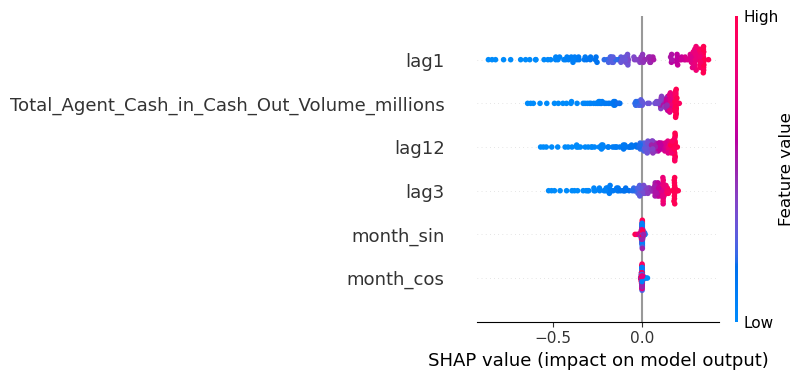

In [39]:
shap.summary_plot(shap_values, X_train)

The interpretation of the model using SHAP shows that the prediction is mainly based on temporal inertia (recent and annual lags), supplemented by seasonal effects and business variables, which confirms the economic consistency of the model.

The SHAP analysis shows that the prediction is based mainly on time inertia (lag 1 and lag 12), supplemented by transaction volume and seasonal effects, which confirms the economic and temporal consistency of the model.

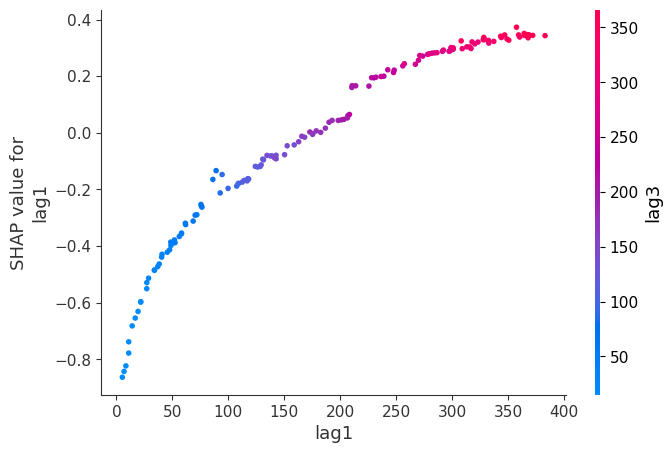

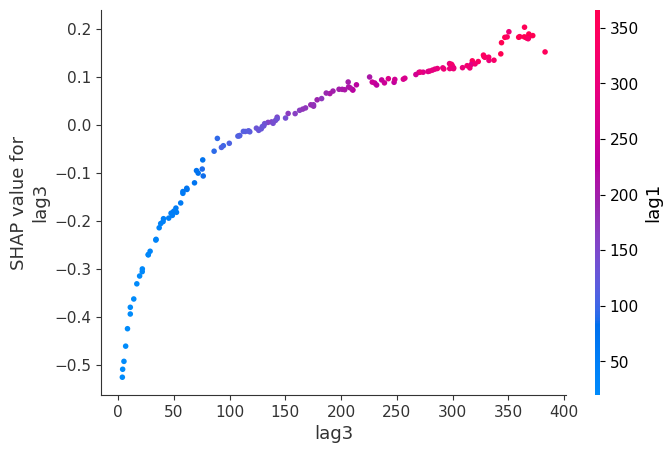

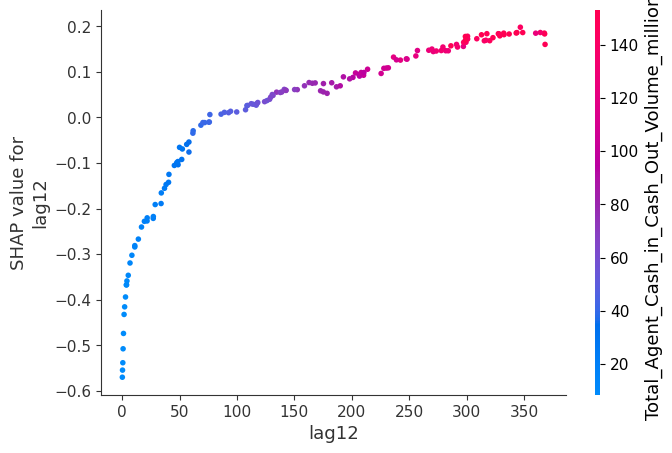

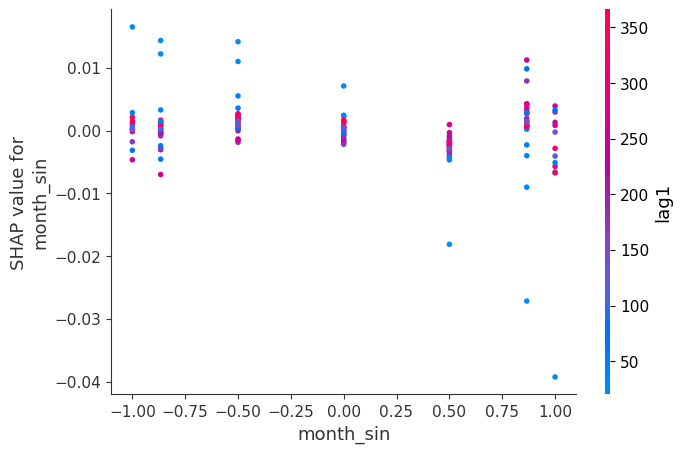

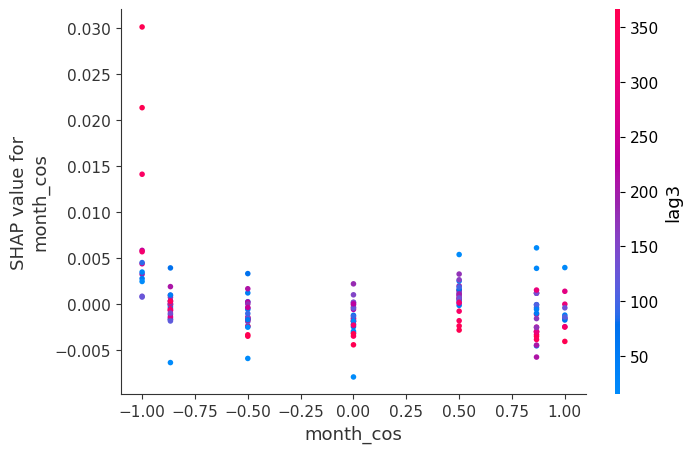

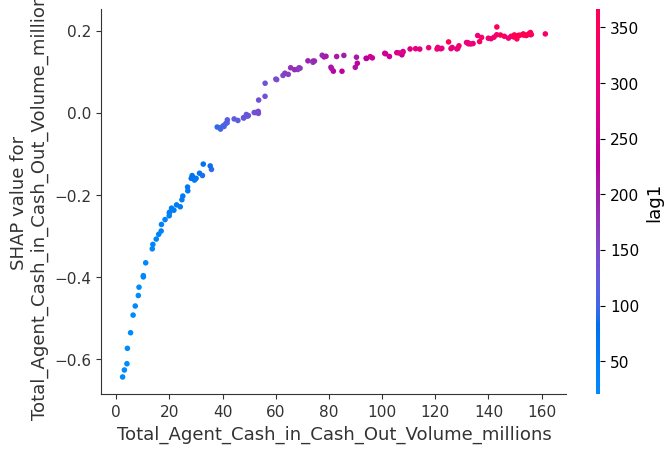

In [41]:
for x in features:
    shap.dependence_plot(x, shap_values, X_train)

In [62]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

xgb.fit(X_train, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [63]:
y_pred_xgb = xgb.predict(X_test)

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

mae_xgb, rmse_xgb


(0.5994537345477472, np.float64(0.6126902313790971))

In [64]:
y_test_real = np.expm1(y_test)
y_pred_xgb_real = np.expm1(y_pred_xgb)

mae_xgb_real = mean_absolute_error(y_test_real, y_pred_xgb_real)
rmse_xgb_real = np.sqrt(mean_squared_error(y_test_real, y_pred_xgb_real))

mae_xgb_real, rmse_xgb_real


(276.04082088656037, np.float64(284.47845470601425))

Graphical analysis shows that the Random Forest model accurately tracks the temporal dynamics of the target variable. The residuals are generally centered around zero, indicating the absence of systematic bias, with larger deviations during periods of high volatility.

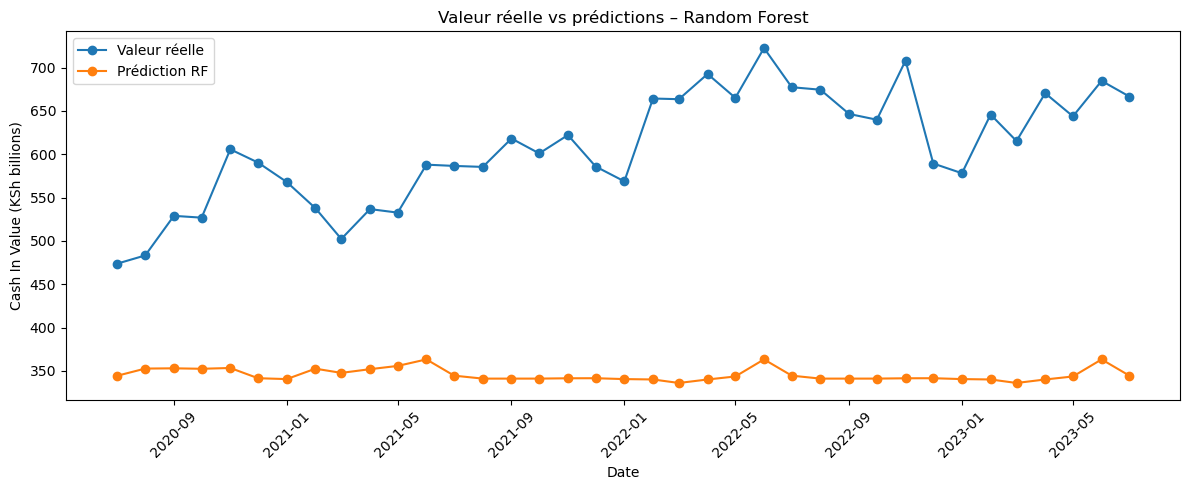

In [65]:
# valeurs réelles et prédites (échelle originale)
y_test_real = np.expm1(y_test)
y_pred_rf_real = np.expm1(y_pred_rf)

plt.figure(figsize=(12, 5))
plt.plot(test["date"], y_test_real, label="Valeur réelle", marker="o")
plt.plot(test["date"], y_pred_rf_real, label="Prédiction RF", marker="o")

plt.title("Valeur réelle vs prédictions – Random Forest")
plt.xlabel("Date")
plt.ylabel("Cash In Value (KSh billions)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


The Random Forest model accurately captures temporal dynamics but exhibits an underestimation of images, an expected behavior for tree-like models trained on volatile economic series. The residuals remain stable over time, indicating good overall robustness.